In [1]:
library(dplyr)
library(tidyr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
hmCG <- read.csv("../output/05-5hmC_CG_chrom100k_subclass_mean_dat_final_with_compartment.csv", stringsAsFactors = FALSE,check.names = F)
head(hmCG);dim(hmCG)

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L6 IT CTX Glut,IT AON-TT-DP Glut,LA-BLA-BMA-PA Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,⋯,Lamp5 Gaba_compartment,Pvalb Gaba_compartment,Sst Gaba_compartment,STR D1 Gaba_compartment,STR D2 Gaba_compartment,ACB-BST-FS D1 Gaba_compartment,Astro-TE NN_compartment,Oligo NN_compartment,OPC NN_compartment,Microglia NN_compartment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,chr1_0,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
2,chr1_1,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
3,chr1_2,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
4,chr1_3,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
5,chr1_4,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
6,chr1_5,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,


[1] 24639    62

In [3]:
subclass_our_liu <- read.csv("../output/01-subclass_our_liu.csv")
head(subclass_our_liu);dim(subclass_our_liu)

,subclass_our,subclass_liu
,<chr>,<chr>
1,L2/3 IT CTX Glut,L2_3_IT_CTX_Glut
2,L4/5 IT CTX Glut,L4_5_IT_CTX_Glut
3,L5 IT CTX Glut,L5_IT_CTX_Glut
4,L6 IT CTX Glut,L6_IT_CTX_Glut
5,IT AON-TT-DP Glut,IT_AON-TT-DP_Glut
6,LA-BLA-BMA-PA Glut,LA-BLA-BMA-PA_Glut


[1] 30  2

In [ ]:
file_list <- list.files(path = "../analysis/m3C_seq/data/AB_compartment_score/", 
                        pattern = "\\.bw$", full.names = FALSE)
head(file_list);length(file_list)

[1] "ABC_NN.compartment_score.100K.bw"                    
[2] "ACB-BST-FS_D1_Gaba.compartment_score.100K.bw"        
[3] "AD_Serpinb7_Glut.compartment_score.100K.bw"          
[4] "ADP-MPO_Trp73_Glut.compartment_score.100K.bw"        
[5] "AHN_Onecut3_Gaba.compartment_score.100K.bw"          
[6] "AHN-RCH-LHA_Otp_Fezf1_Glut.compartment_score.100K.bw"

[1] 273

In [5]:
subclass_liu <- sub("\\.compartment_score\\.100K\\.bw$", "", file_list) %>% data.frame()
colnames(subclass_liu) <- "subclass_liu"
head(subclass_liu);dim(subclass_liu)

,subclass_liu
,<chr>
1,ABC_NN
2,ACB-BST-FS_D1_Gaba
3,AD_Serpinb7_Glut
4,ADP-MPO_Trp73_Glut
5,AHN_Onecut3_Gaba
6,AHN-RCH-LHA_Otp_Fezf1_Glut


[1] 273   1

In [6]:
table(subclass_our_liu$subclass_liu %in% subclass_liu$subclass_liu)


TRUE 
  30 

In [ ]:
subclass_liu_bw <- paste0("../analysis/m3C_seq/data/AB_compartment_score/",
                          subclass_our_liu$subclass_liu,".compartment_score.100K.bw")

subclass_liu_bw

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L2_3_IT_CTX_Glut.compartment_score.100K.bw"     
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L4_5_IT_CTX_Glut.compartment_score.100K.bw"     
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L5_IT_CTX_Glut.compartment_score.100K.bw"       
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L6_IT_CTX_Glut.compartment_score.100K.bw"       
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/IT_AON-TT-DP_Glut.compartment_score.100K.bw"    
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/LA-BLA-BMA-PA_Glut.compartment_score.100K.bw"   
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L2_3_IT_RSP_Glut.compartment_score.100K.bw"     
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L4_RSP-ACA_Glut.compartment_score.100K.bw"      
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L5_ET_CTX_Glut.compartment_score.100K.bw"       
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/SUB-ProS_Glut.compartment_score.100K.bw"        
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/CA1-ProS_Glut.compartment_score.100K.bw"        
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/CA3_Glut.compartment_score.100K.bw"             
[13] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/CLA-EPd-CTX_Car3_Glut.compartment_score.100K.bw"
[14] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L5_NP_CTX_Glut.compartment_score.100K.bw"       
[15] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L6_CT_CTX_Glut.compartment_score.100K.bw"       
[16] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/DG_Glut.compartment_score.100K.bw"              
[17] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/OB_Eomes_Ms4a15_Glut.compartment_score.100K.bw" 
[18] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/OB-in_Frmd7_Gaba.compartment_score.100K.bw"     
[19] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/OB-out_Frmd7_Gaba.compartment_score.100K.bw"    
[20] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/Sncg_Gaba.compartment_score.100K.bw"            
[21] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/Lamp5_Gaba.compartment_score.100K.bw"           
[22] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/Pvalb_Gaba.compartment_score.100K.bw"           
[23] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/Sst_Gaba.compartment_score.100K.bw"             
[24] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/STR_D1_Gaba.compartment_score.100K.bw"          
[25] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/STR_D2_Gaba.compartment_score.100K.bw"          
[26] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/ACB-BST-FS_D1_Gaba.compartment_score.100K.bw"   
[27] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/Astro-TE_NN.compartment_score.100K.bw"          
[28] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/Oligo_NN.compartment_score.100K.bw"           

In [8]:
library(rtracklayer)

Warning message:
“package ‘rtracklayer’ was built under R version 4.3.3”
Loading required package: GenomicRanges

Warning message:
“package ‘GenomicRanges’ was built under R version 4.3.3”
Loading required package: stats4

Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.2”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max

In [9]:
read_bw_to_df <- function(file) {
  data <- as.data.frame(import(file))
  data$subclass <- gsub(".compartment_score.100K.bw","",basename(file))
  return(data)
}

In [10]:
all_bw_data <- lapply(subclass_liu_bw, read_bw_to_df)

combined_df <- do.call(rbind, all_bw_data)

In [11]:
head(combined_df);dim(combined_df)

,seqnames,start,end,width,strand,score,subclass
,<fct>,<int>,<int>,<int>,<fct>,<dbl>,<chr>
1,chr1,1,100000,100000,*,0,L2_3_IT_CTX_Glut
2,chr1,100001,200000,100000,*,0,L2_3_IT_CTX_Glut
3,chr1,200001,300000,100000,*,0,L2_3_IT_CTX_Glut
4,chr1,300001,400000,100000,*,0,L2_3_IT_CTX_Glut
5,chr1,400001,500000,100000,*,0,L2_3_IT_CTX_Glut
6,chr1,500001,600000,100000,*,0,L2_3_IT_CTX_Glut


[1] 790500      7

In [12]:
table(combined_df$subclass %in% subclass_our_liu$subclass_liu)


  TRUE 
790500 

In [13]:
combined_df$subclass <- subclass_our_liu$subclass_our[match(combined_df$subclass,subclass_our_liu$subclass_liu)]

In [14]:
head(combined_df);dim(combined_df)

,seqnames,start,end,width,strand,score,subclass
,<fct>,<int>,<int>,<int>,<fct>,<dbl>,<chr>
1,chr1,1,100000,100000,*,0,L2/3 IT CTX Glut
2,chr1,100001,200000,100000,*,0,L2/3 IT CTX Glut
3,chr1,200001,300000,100000,*,0,L2/3 IT CTX Glut
4,chr1,300001,400000,100000,*,0,L2/3 IT CTX Glut
5,chr1,400001,500000,100000,*,0,L2/3 IT CTX Glut
6,chr1,500001,600000,100000,*,0,L2/3 IT CTX Glut


[1] 790500      7

In [15]:
combined_df <- combined_df %>%
  mutate(chrom100k = paste0(seqnames, "_", (start - 1) %/% 100000))

In [16]:
head(combined_df);dim(combined_df)

,seqnames,start,end,width,strand,score,subclass,chrom100k
,<fct>,<int>,<int>,<int>,<fct>,<dbl>,<chr>,<chr>
1,chr1,1,100000,100000,*,0,L2/3 IT CTX Glut,chr1_0
2,chr1,100001,200000,100000,*,0,L2/3 IT CTX Glut,chr1_1
3,chr1,200001,300000,100000,*,0,L2/3 IT CTX Glut,chr1_2
4,chr1,300001,400000,100000,*,0,L2/3 IT CTX Glut,chr1_3
5,chr1,400001,500000,100000,*,0,L2/3 IT CTX Glut,chr1_4
6,chr1,500001,600000,100000,*,0,L2/3 IT CTX Glut,chr1_5


[1] 790500      8

In [17]:
library(tidyr)

In [18]:
wide_df <- combined_df %>%
  select(chrom100k, score, subclass) %>%
  pivot_wider(
    names_from = subclass,
    values_from = score
  ) %>% data.frame(check.names = FALSE)

In [19]:
wide_df

chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L6 IT CTX Glut,IT AON-TT-DP Glut,LA-BLA-BMA-PA Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1_0,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_1,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_2,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_3,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_4,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_5,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_6,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_7,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_8,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000


In [20]:
head(hmCG);dim(hmCG)

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L6 IT CTX Glut,IT AON-TT-DP Glut,LA-BLA-BMA-PA Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,⋯,Lamp5 Gaba_compartment,Pvalb Gaba_compartment,Sst Gaba_compartment,STR D1 Gaba_compartment,STR D2 Gaba_compartment,ACB-BST-FS D1 Gaba_compartment,Astro-TE NN_compartment,Oligo NN_compartment,OPC NN_compartment,Microglia NN_compartment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,chr1_0,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
2,chr1_1,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
3,chr1_2,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
4,chr1_3,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
5,chr1_4,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
6,chr1_5,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,


[1] 24639    62

In [21]:
grep("compartment$",colnames(hmCG),value = T)

[1] "L2/3 IT CTX Glut_compartment"      "L4/5 IT CTX Glut_compartment"     
 [3] "L5 IT CTX Glut_compartment"        "L6 IT CTX Glut_compartment"       
 [5] "IT AON-TT-DP Glut_compartment"     "LA-BLA-BMA-PA Glut_compartment"   
 [7] "L2/3 IT RSP Glut_compartment"      "L4 RSP-ACA Glut_compartment"      
 [9] "L5 ET CTX Glut_compartment"        "SUB-ProS Glut_compartment"        
[11] "CA1-ProS Glut_compartment"         "CA3 Glut_compartment"             
[13] "CLA-EPd-CTX Car3 Glut_compartment" "L5 NP CTX Glut_compartment"       
[15] "L6 CT CTX Glut_compartment"        "DG Glut_compartment"              
[17] "OB Eomes Ms4a15 Glut_compartment"  "OB-in Frmd7 Gaba_compartment"     
[19] "OB-out Frmd7 Gaba_compartment"     "Sncg Gaba_compartment"            
[21] "Lamp5 Gaba_compartment"            "Pvalb Gaba_compartment"           
[23] "Sst Gaba_compartment"              "STR D1 Gaba_compartment"          
[25] "STR D2 Gaba_compartment"           "ACB-BST-FS D1 Gaba_compartment"   
[27] "Astro-TE NN_compartment"           "Oligo NN_compartment"             
[29] "OPC NN_compartment"                "Microglia NN_compartment"

In [22]:
hmCG <- hmCG %>% dplyr::select(-c(grep("compartment$",colnames(hmCG),value = T),c("Astro-TE NN","Oligo NN","OPC NN","Microglia NN","OEC NN")))

In [23]:
head(hmCG);dim(hmCG)

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L6 IT CTX Glut,IT AON-TT-DP Glut,LA-BLA-BMA-PA Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,⋯,OB Eomes Ms4a15 Glut,OB-in Frmd7 Gaba,OB-out Frmd7 Gaba,Sncg Gaba,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1_0,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,chr1_1,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,chr1_2,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,chr1_3,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,chr1_4,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6,chr1_5,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


[1] 24639    27

In [24]:
table(hmCG$chrom100k %in% wide_df$chrom100k)
table(wide_df$chrom100k %in% hmCG$chrom100k)


 TRUE 
24639 


FALSE  TRUE 
 1711 24639 

In [25]:
wide_df_filter <- wide_df[wide_df$chrom100k %in% hmCG$chrom100k,]

In [26]:
head(wide_df_filter);dim(wide_df_filter)

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L6 IT CTX Glut,IT AON-TT-DP Glut,LA-BLA-BMA-PA Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1_0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,chr1_1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,chr1_2,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
4,chr1_3,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,chr1_4,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,chr1_5,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


[1] 24639    31

In [27]:
table(colnames(wide_df_filter) %in% colnames(hmCG))


FALSE  TRUE 
    4    27 

In [28]:
aaa <- wide_df_filter

In [29]:
wide_df_filter <- wide_df_filter[,colnames(wide_df_filter) %in% colnames(hmCG)]
head(wide_df_filter);dim(wide_df_filter)

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L6 IT CTX Glut,IT AON-TT-DP Glut,LA-BLA-BMA-PA Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,⋯,OB Eomes Ms4a15 Glut,OB-in Frmd7 Gaba,OB-out Frmd7 Gaba,Sncg Gaba,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1_0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,chr1_1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,chr1_2,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
4,chr1_3,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,chr1_4,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,chr1_5,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


[1] 24639    27

In [30]:
wide_df_filter

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L6 IT CTX Glut,IT AON-TT-DP Glut,LA-BLA-BMA-PA Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,⋯,OB Eomes Ms4a15 Glut,OB-in Frmd7 Gaba,OB-out Frmd7 Gaba,Sncg Gaba,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1_0,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000
2,chr1_1,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000
3,chr1_2,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000
4,chr1_3,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000
5,chr1_4,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000
6,chr1_5,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000
7,chr1_6,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000
8,chr1_7,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000
9,chr1_8,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000


In [31]:
wide_df_filter2 <- wide_df_filter %>%
  rowwise() %>%
  mutate(positive_count = sum(c_across(-chrom100k) > 0),
         negative_count = sum(c_across(-chrom100k) < 0),
         count_diff = abs(positive_count - negative_count)) %>%
  ungroup()

In [32]:
wide_df_filter2

chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L6 IT CTX Glut,IT AON-TT-DP Glut,LA-BLA-BMA-PA Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,⋯,Sncg Gaba,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,positive_count,negative_count,count_diff
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>
chr1_0,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0,0,0
chr1_1,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0,0,0
chr1_2,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0,0,0
chr1_3,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0,0,0
chr1_4,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0,0,0
chr1_5,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0,0,0
chr1_6,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0,0,0
chr1_7,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0,0,0
chr1_8,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0,0,0


In [33]:
wide_df_filter2_sorted <- wide_df_filter2 %>%
  arrange(count_diff)

In [34]:
wide_df_filter2_sorted

chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L6 IT CTX Glut,IT AON-TT-DP Glut,LA-BLA-BMA-PA Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,⋯,Sncg Gaba,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,positive_count,negative_count,count_diff
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>
chr1_0,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000000,⋯,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.00000,0,0,0
chr1_1,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000000,⋯,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.00000,0,0,0
chr1_2,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000000,⋯,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.00000,0,0,0
chr1_3,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000000,⋯,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.00000,0,0,0
chr1_4,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000000,⋯,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.00000,0,0,0
chr1_5,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000000,⋯,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.00000,0,0,0
chr1_6,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000000,⋯,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.00000,0,0,0
chr1_7,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000000,⋯,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.00000,0,0,0
chr1_8,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000000,⋯,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000000,0.00000,0,0,0


In [35]:
summary(wide_df_filter2_sorted$count_diff)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00   20.00   26.00   21.32   26.00   26.00 

In [36]:
summary(wide_df_filter2_sorted$negative_count)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    0.00   18.00   14.06   26.00   26.00 

In [37]:
hmCG <- hmCG[hmCG$chrom100k %in% wide_df$chrom100k,]
head(hmCG);dim(hmCG)

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L6 IT CTX Glut,IT AON-TT-DP Glut,LA-BLA-BMA-PA Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,⋯,OB Eomes Ms4a15 Glut,OB-in Frmd7 Gaba,OB-out Frmd7 Gaba,Sncg Gaba,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1_0,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,chr1_1,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,chr1_2,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,chr1_3,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,chr1_4,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6,chr1_5,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


[1] 24639    27

In [38]:
hmCG_1 <- hmCG %>%
  rowwise() %>%
  mutate(positive_count = sum(c_across(-chrom100k) > 0),
         negative_count = sum(c_across(-chrom100k) < 0),
         count_diff = abs(positive_count - negative_count)) %>%
  ungroup()

In [39]:
hmCG_1_sorted <- hmCG_1 %>%
  arrange(count_diff)

In [40]:
hmCG_1_sorted

chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L6 IT CTX Glut,IT AON-TT-DP Glut,LA-BLA-BMA-PA Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,⋯,Sncg Gaba,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,positive_count,negative_count,count_diff
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>
chr7_96,0.005747126,0.013536380,0.04251701,0.062500000,0.025510205,0.000000000,0.01428571,0.00000000,0.00000000,⋯,0.020833334,0.090909090,0.018518519,0.00000000,0.02030457,0.00000000,0.026315790,16,0,16
chr2_1765,0.067479680,0.070881230,0.11987180,0.066666670,0.149999990,0.166666670,0.12250000,0.00000000,0.09090909,⋯,0.156250000,0.259259280,0.102222230,0.16666667,0.05000000,0.00000000,0.000000000,20,0,20
chr2_1763,0.091041670,0.052229296,0.05462963,0.067982460,0.061764702,0.333333340,0.12500000,0.00000000,0.09722223,⋯,0.063157890,0.125000000,0.111111110,0.11111111,0.03164557,0.00000000,0.055555560,21,0,21
chr2_1753,0.060468320,0.102713180,0.09016393,0.054166667,0.137596890,0.000000000,0.11111111,0.30555555,0.11111111,⋯,0.136363640,0.166666670,0.057692308,0.12500000,0.06809524,0.14583334,0.100000000,22,0,22
chr7_215,0.005687584,0.024404762,0.01716418,0.041177080,0.023076924,0.000000000,0.02183757,0.00000000,0.02243590,⋯,0.059343435,0.005434783,0.000000000,0.02564103,0.01239316,0.00000000,0.005747126,22,0,22
chr14_695,0.284987300,0.241591620,0.21014494,0.166666670,0.318750000,0.125000000,0.35465118,0.00000000,0.36458334,⋯,0.147058830,0.363636370,0.360000040,0.15151516,0.25255102,0.00000000,0.171992500,23,0,23
chr2_1754,0.132467540,0.135971230,0.14647886,0.100000000,0.076851850,0.000000000,0.16993465,0.00000000,0.26543210,⋯,0.147368420,0.267857130,0.294117660,0.22222222,0.09933333,0.00000000,0.097701155,23,0,23
chr2_1756,0.161027580,0.078125000,0.10740741,0.050000000,0.059090910,0.200000000,0.12962964,0.00000000,0.18750000,⋯,0.028571429,0.142857150,0.121212125,0.34615386,0.06285311,0.00000000,0.013888889,23,0,23
chr2_1757,0.115204684,0.150752700,0.14330065,0.267857130,0.066666670,0.000000000,0.15656567,0.00000000,0.23913044,⋯,0.025000000,0.178571430,0.083333336,0.17857143,0.09416135,0.00000000,0.125000000,23,0,23


In [41]:
hmCG_1_sorted <- hmCG_1_sorted %>%
  filter(!is.na(count_diff))

In [42]:
hmCG_1_sorted

chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L6 IT CTX Glut,IT AON-TT-DP Glut,LA-BLA-BMA-PA Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,⋯,Sncg Gaba,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,positive_count,negative_count,count_diff
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>
chr7_96,0.005747126,0.013536380,0.04251701,0.062500000,0.025510205,0.000000000,0.01428571,0.00000000,0.00000000,⋯,0.020833334,0.090909090,0.018518519,0.00000000,0.02030457,0.00000000,0.026315790,16,0,16
chr2_1765,0.067479680,0.070881230,0.11987180,0.066666670,0.149999990,0.166666670,0.12250000,0.00000000,0.09090909,⋯,0.156250000,0.259259280,0.102222230,0.16666667,0.05000000,0.00000000,0.000000000,20,0,20
chr2_1763,0.091041670,0.052229296,0.05462963,0.067982460,0.061764702,0.333333340,0.12500000,0.00000000,0.09722223,⋯,0.063157890,0.125000000,0.111111110,0.11111111,0.03164557,0.00000000,0.055555560,21,0,21
chr2_1753,0.060468320,0.102713180,0.09016393,0.054166667,0.137596890,0.000000000,0.11111111,0.30555555,0.11111111,⋯,0.136363640,0.166666670,0.057692308,0.12500000,0.06809524,0.14583334,0.100000000,22,0,22
chr7_215,0.005687584,0.024404762,0.01716418,0.041177080,0.023076924,0.000000000,0.02183757,0.00000000,0.02243590,⋯,0.059343435,0.005434783,0.000000000,0.02564103,0.01239316,0.00000000,0.005747126,22,0,22
chr14_695,0.284987300,0.241591620,0.21014494,0.166666670,0.318750000,0.125000000,0.35465118,0.00000000,0.36458334,⋯,0.147058830,0.363636370,0.360000040,0.15151516,0.25255102,0.00000000,0.171992500,23,0,23
chr2_1754,0.132467540,0.135971230,0.14647886,0.100000000,0.076851850,0.000000000,0.16993465,0.00000000,0.26543210,⋯,0.147368420,0.267857130,0.294117660,0.22222222,0.09933333,0.00000000,0.097701155,23,0,23
chr2_1756,0.161027580,0.078125000,0.10740741,0.050000000,0.059090910,0.200000000,0.12962964,0.00000000,0.18750000,⋯,0.028571429,0.142857150,0.121212125,0.34615386,0.06285311,0.00000000,0.013888889,23,0,23
chr2_1757,0.115204684,0.150752700,0.14330065,0.267857130,0.066666670,0.000000000,0.15656567,0.00000000,0.23913044,⋯,0.025000000,0.178571430,0.083333336,0.17857143,0.09416135,0.00000000,0.125000000,23,0,23


In [43]:
summary(hmCG_1_sorted$count_diff)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
     16      26      26      26      26      26 

In [44]:
summary(hmCG_1_sorted$negative_count)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      0       0       0       0       0       0 

In [45]:
merged_df <- merge(wide_df_filter, hmCG, by = "chrom100k", suffixes = c("_3C", "_hmCG"))

In [46]:
head(merged_df);dim(merged_df)

,chrom100k,L2/3 IT CTX Glut_3C,L4/5 IT CTX Glut_3C,L5 IT CTX Glut_3C,L6 IT CTX Glut_3C,IT AON-TT-DP Glut_3C,LA-BLA-BMA-PA Glut_3C,L2/3 IT RSP Glut_3C,L4 RSP-ACA Glut_3C,L5 ET CTX Glut_3C,⋯,OB Eomes Ms4a15 Glut_hmCG,OB-in Frmd7 Gaba_hmCG,OB-out Frmd7 Gaba_hmCG,Sncg Gaba_hmCG,Lamp5 Gaba_hmCG,Pvalb Gaba_hmCG,Sst Gaba_hmCG,STR D1 Gaba_hmCG,STR D2 Gaba_hmCG,ACB-BST-FS D1 Gaba_hmCG
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1_0,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.0000000,0.0000000,0.000000,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,chr1_1,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.0000000,0.0000000,0.000000,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,chr1_10,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.0000000,0.0000000,0.000000,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,chr1_100,-3.553936,0.7758843,2.683697,-2.528243,0.6797727,-4.283804,-0.2897587,0.4430414,5.251019,⋯,0.1980844,0.1484985,0.12960170,0.2440823,0.2834850,0.3126369,0.3098496,0.2304022,0.1624046,0.2759126
5,chr1_1000,-19.238665,-19.4752712,-14.370521,-20.941557,-11.2771664,-8.810387,-19.2338257,-4.7738547,-6.669826,⋯,0.1745122,0.1273402,0.11893264,0.2594466,0.2620722,0.3460626,0.3012467,0.2763888,0.1732374,0.2916362
6,chr1_1001,-19.035269,-19.7375679,-14.601047,-20.930523,-11.6334047,-9.037502,-19.3711510,-4.7195754,-7.194997,⋯,0.1533592,0.1116161,0.09650505,0.2215029,0.2452355,0.3200099,0.2901749,0.2511972,0.1358427,0.2911570


[1] 24639    53

In [47]:
merged_df <- merged_df %>%
  filter(rowSums(!is.na(select(., ends_with("_3C")))) > 0 &
         rowSums(!is.na(select(., ends_with("_hmCG")))) > 0)

In [48]:
head(merged_df);dim(merged_df);merged_df

,chrom100k,L2/3 IT CTX Glut_3C,L4/5 IT CTX Glut_3C,L5 IT CTX Glut_3C,L6 IT CTX Glut_3C,IT AON-TT-DP Glut_3C,LA-BLA-BMA-PA Glut_3C,L2/3 IT RSP Glut_3C,L4 RSP-ACA Glut_3C,L5 ET CTX Glut_3C,⋯,OB Eomes Ms4a15 Glut_hmCG,OB-in Frmd7 Gaba_hmCG,OB-out Frmd7 Gaba_hmCG,Sncg Gaba_hmCG,Lamp5 Gaba_hmCG,Pvalb Gaba_hmCG,Sst Gaba_hmCG,STR D1 Gaba_hmCG,STR D2 Gaba_hmCG,ACB-BST-FS D1 Gaba_hmCG
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1_100,-3.553936,0.7758843,2.683697,-2.528243,0.6797727,-4.283804,-0.2897587,0.4430414,5.251019,⋯,0.1980844,0.14849848,0.12960170,0.2440823,0.2834850,0.3126369,0.3098496,0.2304022,0.1624046,0.2759126
2,chr1_1000,-19.238665,-19.4752712,-14.370521,-20.941557,-11.2771664,-8.810387,-19.2338257,-4.7738547,-6.669826,⋯,0.1745122,0.12734017,0.11893264,0.2594466,0.2620722,0.3460626,0.3012467,0.2763888,0.1732374,0.2916362
3,chr1_1001,-19.035269,-19.7375679,-14.601047,-20.930523,-11.6334047,-9.037502,-19.3711510,-4.7195754,-7.194997,⋯,0.1533592,0.11161607,0.09650505,0.2215029,0.2452355,0.3200099,0.2901749,0.2511972,0.1358427,0.2911570
4,chr1_1002,-18.984188,-20.5303745,-14.734402,-20.863432,-11.4684801,-9.594769,-19.9385986,-4.6044865,-8.166672,⋯,0.1537687,0.11210279,0.08838881,0.2239025,0.2306409,0.3045246,0.2926865,0.2487776,0.1323986,0.2774625
5,chr1_1003,-19.187643,-21.4101028,-14.690858,-20.694542,-12.1602421,-10.173169,-20.0816803,-4.6453247,-8.879954,⋯,0.1661210,0.09122451,0.09330063,0.2247011,0.2454354,0.3285080,0.2840984,0.2404914,0.1440164,0.2977917
6,chr1_1004,-19.585564,-22.2606010,-15.460505,-20.876049,-12.6623039,-11.300467,-20.0073833,-5.3280678,-9.287308,⋯,0.1711004,0.10584231,0.07488758,0.2214059,0.2435905,0.3163938,0.2891827,0.2574824,0.2088918,0.3003006


[1] 24032    53

chrom100k,L2/3 IT CTX Glut_3C,L4/5 IT CTX Glut_3C,L5 IT CTX Glut_3C,L6 IT CTX Glut_3C,IT AON-TT-DP Glut_3C,LA-BLA-BMA-PA Glut_3C,L2/3 IT RSP Glut_3C,L4 RSP-ACA Glut_3C,L5 ET CTX Glut_3C,⋯,OB Eomes Ms4a15 Glut_hmCG,OB-in Frmd7 Gaba_hmCG,OB-out Frmd7 Gaba_hmCG,Sncg Gaba_hmCG,Lamp5 Gaba_hmCG,Pvalb Gaba_hmCG,Sst Gaba_hmCG,STR D1 Gaba_hmCG,STR D2 Gaba_hmCG,ACB-BST-FS D1 Gaba_hmCG
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1_100,-3.553936,0.7758843,2.683697,-2.528243,0.6797727,-4.283804,-0.2897587,0.4430414,5.251019,⋯,0.19808443,0.14849848,0.12960170,0.2440823,0.2834850,0.3126369,0.3098496,0.2304022,0.16240464,0.2759126
chr1_1000,-19.238665,-19.4752712,-14.370521,-20.941557,-11.2771664,-8.810387,-19.2338257,-4.7738547,-6.669826,⋯,0.17451220,0.12734017,0.11893264,0.2594466,0.2620722,0.3460626,0.3012467,0.2763888,0.17323737,0.2916362
chr1_1001,-19.035269,-19.7375679,-14.601047,-20.930523,-11.6334047,-9.037502,-19.3711510,-4.7195754,-7.194997,⋯,0.15335917,0.11161607,0.09650505,0.2215029,0.2452355,0.3200099,0.2901749,0.2511972,0.13584265,0.2911570
chr1_1002,-18.984188,-20.5303745,-14.734402,-20.863432,-11.4684801,-9.594769,-19.9385986,-4.6044865,-8.166672,⋯,0.15376866,0.11210279,0.08838881,0.2239025,0.2306409,0.3045246,0.2926865,0.2487776,0.13239858,0.2774625
chr1_1003,-19.187643,-21.4101028,-14.690858,-20.694542,-12.1602421,-10.173169,-20.0816803,-4.6453247,-8.879954,⋯,0.16612098,0.09122451,0.09330063,0.2247011,0.2454354,0.3285080,0.2840984,0.2404914,0.14401643,0.2977917
chr1_1004,-19.585564,-22.2606010,-15.460505,-20.876049,-12.6623039,-11.300467,-20.0073833,-5.3280678,-9.287308,⋯,0.17110036,0.10584231,0.07488758,0.2214059,0.2435905,0.3163938,0.2891827,0.2574824,0.20889182,0.3003006
chr1_1005,-19.919979,-22.9114437,-16.544918,-21.238493,-12.5437098,-12.181407,-19.9849224,-6.2021523,-10.367149,⋯,0.09980722,0.06736781,0.06369090,0.1379170,0.1566550,0.2075513,0.1875348,0.1572923,0.09425001,0.1763810
chr1_1006,-20.073053,-23.1113091,-17.116695,-21.321949,-12.6731510,-12.618347,-20.0841274,-6.1523123,-11.021721,⋯,0.13894248,0.06318188,0.07157067,0.1385986,0.1746565,0.1982849,0.1961330,0.1839391,0.11956538,0.2139864
chr1_1007,-20.168646,-23.0044994,-16.780684,-21.192411,-12.7821560,-12.392469,-20.2962627,-5.5924702,-11.686172,⋯,0.11878348,0.07465762,0.08238081,0.1367319,0.1584811,0.2097336,0.1955994,0.1642378,0.08803363,0.1858757


In [49]:
correlation_5hmCG <- merged_df %>%
  rowwise() %>%
  mutate(correlation = cor(
    c_across(ends_with("_3C")), 
    c_across(ends_with("_hmCG")), 
    use = "complete.obs"
  )) %>%
  ungroup() %>%
  select(chrom100k, correlation)

Warning message:
“There were 295 warnings in `mutate()`.
The first warning was:
ℹ In argument: `correlation = cor(...)`.
ℹ In row 1762.
Caused by warning in `cor()`:
! the standard deviation is zero
ℹ Run `dplyr::last_dplyr_warnings()` to see the 294 remaining warnings.”


In [50]:
head(correlation_5hmCG);dim(correlation_5hmCG);correlation_5hmCG

chrom100k,correlation
<chr>,<dbl>
chr1_100,0.2180242
chr1_1000,0.2593081
chr1_1001,0.2795819
chr1_1002,0.2828362
chr1_1003,0.3068630
chr1_1004,0.3060237


[1] 24032     2

chrom100k,correlation
<chr>,<dbl>
chr1_100,0.21802421
chr1_1000,0.25930814
chr1_1001,0.27958191
chr1_1002,0.28283620
chr1_1003,0.30686297
chr1_1004,0.30602371
chr1_1005,0.17528066
chr1_1006,0.24865629
chr1_1007,0.17084597


In [51]:
top_100_correlation <- correlation_5hmCG %>%
  arrange(desc(correlation)) %>%
  head(100)

In [52]:
top_100_correlation

chrom100k,correlation
<chr>,<dbl>
chr1_684,0.8991851
chr1_681,0.8925215
chr1_685,0.8909193
chr1_688,0.8858125
chr1_683,0.8852501
chr1_686,0.8815367
chr6_91,0.8789643
chr1_687,0.8661270
chr1_682,0.8620788


In [51]:
# top_10_correlation

chrom100k,correlation
<chr>,<dbl>
chr6_91,0.9332424
chr6_90,0.8862362
chr6_92,0.8688083
chr1_684,0.8646606
chr1_681,0.8644123
chr1_683,0.8582531
chr8_171,0.8538309
chr1_685,0.8497763
chr8_172,0.8481381


In [52]:
# top_100_correlation

chrom100k,correlation
<chr>,<dbl>
chr6_91,0.9332424
chr6_90,0.8862362
chr6_92,0.8688083
chr1_684,0.8646606
chr1_681,0.8644123
chr1_683,0.8582531
chr8_171,0.8538309
chr1_685,0.8497763
chr8_172,0.8481381


In [53]:
head(aaa);dim(aaa)

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L6 IT CTX Glut,IT AON-TT-DP Glut,LA-BLA-BMA-PA Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1_0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,chr1_1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,chr1_2,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
4,chr1_3,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,chr1_4,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,chr1_5,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


[1] 24639    31

In [54]:
library(tidyverse)

Warning message:
“package ‘tidyverse’ was built under R version 4.3.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘readr’ was built under R version 4.3.3”
Warning message:
“package ‘stringr’ was built under R version 4.3.2”
Warning message:
“package ‘forcats’ was built under R version 4.3.3”
── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.2     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%within%()   masks IRanges::%within%()
✖ IRanges::collapse()     masks dplyr::collapse()
✖ BiocGenerics::combine() masks dplyr::combine()
✖ IRanges::desc()         masks dplyr::desc()
✖ S4V

In [55]:
rownames(aaa) <- NULL
aaa <- aaa %>% column_to_rownames("chrom100k")
aaa

,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L6 IT CTX Glut,IT AON-TT-DP Glut,LA-BLA-BMA-PA Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1_0,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_1,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_2,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_3,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_4,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_5,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_6,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_7,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_8,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000


In [56]:
# wide_df_filter2_sorted[wide_df_filter2_sorted$chrom100k %in% top_100_correlation$chrom100k,]
# aaa[aaa$chrom100k %in% top_100_correlation$chrom100k,]
aaa[top_100_correlation$chrom100k,]

,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L6 IT CTX Glut,IT AON-TT-DP Glut,LA-BLA-BMA-PA Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1_684,-21.0019131,-22.8019695,-17.6637058,-20.8521023,-10.0546207,-13.5139589,-19.7576160,-7.0102181,-11.37500286,-9.5557747,⋯,19.1355705,19.2400284,0.39231792,-14.1597672,-16.4295979,-1.33612943,-23.934786,11.710055,5.933852,-22.48502
chr1_681,-19.9911766,-22.2048416,-17.1574421,-20.2643089,-8.7810764,-11.8755188,-19.8773232,-7.0404377,-9.90766239,-9.2317352,⋯,18.3947372,19.4562016,-0.92605877,-14.5331583,-15.7510662,-0.65091646,-23.469599,7.094840,2.024969,-22.32039
chr1_685,-20.8778267,-22.9588413,-17.8463497,-20.9046040,-10.1031599,-13.5398207,-19.6111317,-7.6794467,-12.06281567,-9.8181877,⋯,19.0420456,18.7861080,0.08835205,-13.8268147,-16.3433876,-0.95872903,-24.207258,12.666469,6.904790,-22.46460
chr1_688,-19.9584198,-21.8599434,-17.2033691,-20.2957554,-9.7066002,-12.7172203,-19.7323265,-7.6606078,-11.95613956,-8.8445301,⋯,20.0480270,18.7640381,3.80841398,-12.2045765,-15.5612965,0.39810047,-22.321455,15.741893,12.651629,-22.34919
chr1_683,-20.5660629,-22.5174999,-17.3582325,-20.5890388,-10.0644836,-12.8387480,-19.9468269,-6.5789585,-10.71291351,-8.7085638,⋯,18.9553452,19.4787407,1.03743088,-14.2129087,-16.4963818,-1.61582506,-23.897108,10.319252,5.297956,-22.44591
chr1_686,-20.3239841,-22.8279877,-17.6353207,-20.6415462,-10.0731840,-12.7573166,-19.4949741,-7.9449821,-12.44924831,-10.2096052,⋯,19.5622749,18.5601273,2.04196930,-12.9319820,-16.2846394,-0.36364704,-24.136398,13.899316,9.005047,-22.37952
chr6_91,-17.1333885,-19.1704750,-13.6397924,-16.3137970,-8.9313412,-12.0610132,-15.7887154,-6.4391065,-11.25715351,-10.2211332,⋯,6.0399389,10.8534403,8.39570713,-16.9801960,-17.1903858,-5.86707354,-17.584929,-14.271479,9.510084,-20.05058
chr1_687,-20.0736294,-22.4233341,-17.4089603,-20.3383503,-9.9295940,-12.4207687,-19.5313301,-8.0351782,-12.36152935,-9.7116556,⋯,20.0411777,18.5561657,4.08434916,-12.2048273,-15.7868671,0.09105674,-23.337614,15.073786,11.414127,-22.32756
chr1_682,-20.1009750,-22.2599449,-17.1667652,-20.2962151,-9.6502256,-12.0697718,-19.9304371,-6.8376560,-10.05205631,-8.4581680,⋯,18.6072540,19.5301342,0.57629949,-14.3630362,-16.3054199,-1.23806512,-23.866413,8.609097,3.590092,-22.38929


In [57]:
top100_3C <- aaa[top_100_correlation$chrom100k,]

In [58]:
# top100_3C[top100_3C$chrom100k == "chr6_91",]
top100_3C["chr6_91",]

,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L6 IT CTX Glut,IT AON-TT-DP Glut,LA-BLA-BMA-PA Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr6_91,-17.13339,-19.17048,-13.63979,-16.3138,-8.931341,-12.06101,-15.78872,-6.439106,-11.25715,-10.22113,⋯,6.039939,10.85344,8.395707,-16.9802,-17.19039,-5.867074,-17.58493,-14.27148,9.510084,-20.05058


In [59]:
top100_3C["chr1_684",]

,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L6 IT CTX Glut,IT AON-TT-DP Glut,LA-BLA-BMA-PA Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1_684,-21.00191,-22.80197,-17.66371,-20.8521,-10.05462,-13.51396,-19.75762,-7.010218,-11.375,-9.555775,⋯,19.13557,19.24003,0.3923179,-14.15977,-16.4296,-1.336129,-23.93479,11.71006,5.933852,-22.48502


In [60]:
saveRDS(top100_3C,"../output/07-merged_df_top100_3C_5hmCG_neuron.rds")

In [61]:
merged_df

chrom100k,L2/3 IT CTX Glut_3C,L4/5 IT CTX Glut_3C,L5 IT CTX Glut_3C,L6 IT CTX Glut_3C,IT AON-TT-DP Glut_3C,LA-BLA-BMA-PA Glut_3C,L2/3 IT RSP Glut_3C,L4 RSP-ACA Glut_3C,L5 ET CTX Glut_3C,⋯,OB Eomes Ms4a15 Glut_hmCG,OB-in Frmd7 Gaba_hmCG,OB-out Frmd7 Gaba_hmCG,Sncg Gaba_hmCG,Lamp5 Gaba_hmCG,Pvalb Gaba_hmCG,Sst Gaba_hmCG,STR D1 Gaba_hmCG,STR D2 Gaba_hmCG,ACB-BST-FS D1 Gaba_hmCG
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1_100,-3.553936,0.7758843,2.683697,-2.528243,0.6797727,-4.283804,-0.2897587,0.4430414,5.251019,⋯,0.19808443,0.14849848,0.12960170,0.2440823,0.2834850,0.3126369,0.3098496,0.2304022,0.16240464,0.2759126
chr1_1000,-19.238665,-19.4752712,-14.370521,-20.941557,-11.2771664,-8.810387,-19.2338257,-4.7738547,-6.669826,⋯,0.17451220,0.12734017,0.11893264,0.2594466,0.2620722,0.3460626,0.3012467,0.2763888,0.17323737,0.2916362
chr1_1001,-19.035269,-19.7375679,-14.601047,-20.930523,-11.6334047,-9.037502,-19.3711510,-4.7195754,-7.194997,⋯,0.15335917,0.11161607,0.09650505,0.2215029,0.2452355,0.3200099,0.2901749,0.2511972,0.13584265,0.2911570
chr1_1002,-18.984188,-20.5303745,-14.734402,-20.863432,-11.4684801,-9.594769,-19.9385986,-4.6044865,-8.166672,⋯,0.15376866,0.11210279,0.08838881,0.2239025,0.2306409,0.3045246,0.2926865,0.2487776,0.13239858,0.2774625
chr1_1003,-19.187643,-21.4101028,-14.690858,-20.694542,-12.1602421,-10.173169,-20.0816803,-4.6453247,-8.879954,⋯,0.16612098,0.09122451,0.09330063,0.2247011,0.2454354,0.3285080,0.2840984,0.2404914,0.14401643,0.2977917
chr1_1004,-19.585564,-22.2606010,-15.460505,-20.876049,-12.6623039,-11.300467,-20.0073833,-5.3280678,-9.287308,⋯,0.17110036,0.10584231,0.07488758,0.2214059,0.2435905,0.3163938,0.2891827,0.2574824,0.20889182,0.3003006
chr1_1005,-19.919979,-22.9114437,-16.544918,-21.238493,-12.5437098,-12.181407,-19.9849224,-6.2021523,-10.367149,⋯,0.09980722,0.06736781,0.06369090,0.1379170,0.1566550,0.2075513,0.1875348,0.1572923,0.09425001,0.1763810
chr1_1006,-20.073053,-23.1113091,-17.116695,-21.321949,-12.6731510,-12.618347,-20.0841274,-6.1523123,-11.021721,⋯,0.13894248,0.06318188,0.07157067,0.1385986,0.1746565,0.1982849,0.1961330,0.1839391,0.11956538,0.2139864
chr1_1007,-20.168646,-23.0044994,-16.780684,-21.192411,-12.7821560,-12.392469,-20.2962627,-5.5924702,-11.686172,⋯,0.11878348,0.07465762,0.08238081,0.1367319,0.1584811,0.2097336,0.1955994,0.1642378,0.08803363,0.1858757


In [62]:
max_correlation_row <- correlation_5hmCG %>%
  filter(correlation == max(correlation, na.rm = TRUE))

In [63]:
max_correlation_row

chrom100k,correlation
<chr>,<dbl>
chr1_684,0.8991851


In [64]:
max_chrom100k <- max_correlation_row$chrom100k
max_chrom100k

[1] "chr1_684"

In [65]:
merged_df_max_5hmCG <- merged_df[merged_df$chrom100k == max_chrom100k,]
merged_df_max_5hmCG

,chrom100k,L2/3 IT CTX Glut_3C,L4/5 IT CTX Glut_3C,L5 IT CTX Glut_3C,L6 IT CTX Glut_3C,IT AON-TT-DP Glut_3C,LA-BLA-BMA-PA Glut_3C,L2/3 IT RSP Glut_3C,L4 RSP-ACA Glut_3C,L5 ET CTX Glut_3C,⋯,OB Eomes Ms4a15 Glut_hmCG,OB-in Frmd7 Gaba_hmCG,OB-out Frmd7 Gaba_hmCG,Sncg Gaba_hmCG,Lamp5 Gaba_hmCG,Pvalb Gaba_hmCG,Sst Gaba_hmCG,STR D1 Gaba_hmCG,STR D2 Gaba_hmCG,ACB-BST-FS D1 Gaba_hmCG
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1578,chr1_684,-21.00191,-22.80197,-17.66371,-20.8521,-10.05462,-13.51396,-19.75762,-7.010218,-11.375,⋯,0.1455568,0.2343802,0.1822651,0.3835685,0.4465381,0.4863469,0.3731105,0.2229533,0.2159099,0.3042032


In [66]:
wide_df

chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L6 IT CTX Glut,IT AON-TT-DP Glut,LA-BLA-BMA-PA Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1_0,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_1,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_2,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_3,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_4,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_5,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_6,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_7,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_8,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000


In [67]:
merged_df_max_5hmCG_all <- wide_df[wide_df$chrom100k == max_chrom100k,]
merged_df_max_5hmCG_all

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L6 IT CTX Glut,IT AON-TT-DP Glut,LA-BLA-BMA-PA Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
685,chr1_684,-21.00191,-22.80197,-17.66371,-20.8521,-10.05462,-13.51396,-19.75762,-7.010218,-11.375,⋯,19.13557,19.24003,0.3923179,-14.15977,-16.4296,-1.336129,-23.93479,11.71006,5.933852,-22.48502


In [68]:
saveRDS(merged_df_max_5hmCG_all,"../output/07-merged_df_max_5hmCG_neuron_and_non_neuron.rds")

In [69]:
saveRDS(merged_df_max_5hmCG,"../output/07-merged_df_max_5hmCG_neuron.rds")

In [70]:
colnames(wide_df_filter)

[1] "chrom100k"             "L2/3 IT CTX Glut"      "L4/5 IT CTX Glut"     
 [4] "L5 IT CTX Glut"        "L6 IT CTX Glut"        "IT AON-TT-DP Glut"    
 [7] "LA-BLA-BMA-PA Glut"    "L2/3 IT RSP Glut"      "L4 RSP-ACA Glut"      
[10] "L5 ET CTX Glut"        "SUB-ProS Glut"         "CA1-ProS Glut"        
[13] "CA3 Glut"              "CLA-EPd-CTX Car3 Glut" "L5 NP CTX Glut"       
[16] "L6 CT CTX Glut"        "DG Glut"               "OB Eomes Ms4a15 Glut" 
[19] "OB-in Frmd7 Gaba"      "OB-out Frmd7 Gaba"     "Sncg Gaba"            
[22] "Lamp5 Gaba"            "Pvalb Gaba"            "Sst Gaba"             
[25] "STR D1 Gaba"           "STR D2 Gaba"           "ACB-BST-FS D1 Gaba"

In [71]:
subclass_columns <- colnames(wide_df_filter)[-1]
subclass_columns

[1] "L2/3 IT CTX Glut"      "L4/5 IT CTX Glut"      "L5 IT CTX Glut"       
 [4] "L6 IT CTX Glut"        "IT AON-TT-DP Glut"     "LA-BLA-BMA-PA Glut"   
 [7] "L2/3 IT RSP Glut"      "L4 RSP-ACA Glut"       "L5 ET CTX Glut"       
[10] "SUB-ProS Glut"         "CA1-ProS Glut"         "CA3 Glut"             
[13] "CLA-EPd-CTX Car3 Glut" "L5 NP CTX Glut"        "L6 CT CTX Glut"       
[16] "DG Glut"               "OB Eomes Ms4a15 Glut"  "OB-in Frmd7 Gaba"     
[19] "OB-out Frmd7 Gaba"     "Sncg Gaba"             "Lamp5 Gaba"           
[22] "Pvalb Gaba"            "Sst Gaba"              "STR D1 Gaba"          
[25] "STR D2 Gaba"           "ACB-BST-FS D1 Gaba"

In [ ]:
calculate_correlation <- function(data_path) {

  read_and_fix <- function(file_path) {
    df <- read.csv(file_path, stringsAsFactors = FALSE, check.names = FALSE)
    if (colnames(df)[1] == "") {
      colnames(df)[1] <- "chrom100k"
      message("The first column name in the file '", file_path, "' was empty and has been replaced with 'chrom100k'.")
    }
    return(df)
  }

  data <- read_and_fix(data_path)
  print(dim(data))

  data <- data %>%
    dplyr::select(-c(grep("compartment$", colnames(data), value = TRUE), c("Astro-TE NN","Oligo NN","OPC NN","Microglia NN","OEC NN")))

  subclass_our_liu <- read.csv("../output/01-subclass_our_liu.csv")

  bw_dir <- "../analysis/m3C_seq/data/AB_compartment_score/"

  file_list <- list.files(path = bw_dir, pattern = "\\.bw$", full.names = FALSE)
  subclass_liu <- sub("\\.compartment_score\\.100K\\.bw$", "", file_list) %>% data.frame()
  colnames(subclass_liu) <- "subclass_liu"

  subclass_liu_bw <- paste0(bw_dir, "/", subclass_our_liu$subclass_liu, ".compartment_score.100K.bw")

  read_bw_to_df <- function(file) {
    data <- as.data.frame(import(file))
    data$subclass <- gsub(".compartment_score.100K.bw", "", basename(file))
    return(data)
  }

  all_bw_data <- lapply(subclass_liu_bw, read_bw_to_df)
  combined_df <- do.call(rbind, all_bw_data)

  combined_df$subclass <- subclass_our_liu$subclass_our[match(combined_df$subclass, subclass_our_liu$subclass_liu)]

  combined_df <- combined_df %>%
    mutate(chrom100k = paste0(seqnames, "_", (start - 1) %/% 100000))

  wide_df <- combined_df %>%
    select(chrom100k, score, subclass) %>%
    pivot_wider(
      names_from = subclass,
      values_from = score
    ) %>%
    data.frame(check.names = FALSE)

  print(table(data$chrom100k %in% wide_df$chrom100k))
  print(table(wide_df$chrom100k %in% data$chrom100k))

  wide_df_filter <- wide_df[wide_df$chrom100k %in% data$chrom100k, ]
  wide_df_filter <- wide_df_filter[,colnames(wide_df_filter) %in% colnames(data)]
  data <- data[data$chrom100k %in% wide_df$chrom100k, ]

  merged_df <- merge(wide_df_filter, data, by = "chrom100k", suffixes = c("_3C", "_data"))

  merged_df <- merged_df %>%
  filter(rowSums(!is.na(select(., ends_with("_3C")))) > 0 &
         rowSums(!is.na(select(., ends_with("_data")))) > 0)

  correlation_df <- merged_df %>%
  rowwise() %>%
  mutate(correlation = cor(
    c_across(ends_with("_3C")), 
    c_across(ends_with("_data")), 
    use = "complete.obs"
  )) %>%
  ungroup() %>%
  select(chrom100k, correlation)

#   subclass_columns <- colnames(wide_df_filter)[-1]

  return(correlation_df)
}

In [73]:
cor_5hmCG <- calculate_correlation("../output/05-5hmC_CG_chrom100k_subclass_mean_dat_final_with_compartment.csv")
cor_5hmCG

[1] 24639    62

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


Warning message:
“There were 295 warnings in `mutate()`.
The first warning was:
ℹ In argument: `correlation = cor(...)`.
ℹ In row 1762.
Caused by warning in `cor()`:
! the standard deviation is zero
ℹ Run `dplyr::last_dplyr_warnings()` to see the 294 remaining warnings.”


chrom100k,correlation
<chr>,<dbl>
chr1_100,0.21802421
chr1_1000,0.25930814
chr1_1001,0.27958191
chr1_1002,0.28283620
chr1_1003,0.30686297
chr1_1004,0.30602371
chr1_1005,0.17528066
chr1_1006,0.24865629
chr1_1007,0.17084597


In [74]:
cor_5hmCG_5mCG <- calculate_correlation("../output/05-5mC_CG_chrom100k_subclass_mean_dat_final_with_compartment.csv")
cor_5hmCG_5mCG

[1] 24639    62

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


Warning message:
“There were 295 warnings in `mutate()`.
The first warning was:
ℹ In argument: `correlation = cor(...)`.
ℹ In row 1762.
Caused by warning in `cor()`:
! the standard deviation is zero
ℹ Run `dplyr::last_dplyr_warnings()` to see the 294 remaining warnings.”


chrom100k,correlation
<chr>,<dbl>
chr1_100,0.557252844
chr1_1000,-0.041969982
chr1_1001,0.074417427
chr1_1002,-0.054007662
chr1_1003,-0.067288519
chr1_1004,-0.140990197
chr1_1005,0.105757637
chr1_1006,-0.010972423
chr1_1007,0.001742812


In [75]:
cor_5mCG <- calculate_correlation("../output/05-true5mC_CG_chrom100k_subclass_mean_dat_final_with_compartment.csv")
cor_5mCG

The first column name in the file '../output/05-true5mC_CG_chrom100k_subclass_mean_dat_final_with_compartment.csv' was empty and has been replaced with 'chrom100k'.



[1] 24639    62

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


Warning message:
“There were 295 warnings in `mutate()`.
The first warning was:
ℹ In argument: `correlation = cor(...)`.
ℹ In row 1762.
Caused by warning in `cor()`:
! the standard deviation is zero
ℹ Run `dplyr::last_dplyr_warnings()` to see the 294 remaining warnings.”


chrom100k,correlation
<chr>,<dbl>
chr1_100,0.03328609
chr1_1000,-0.27148129
chr1_1001,-0.24346956
chr1_1002,-0.32369290
chr1_1003,-0.37181961
chr1_1004,-0.36655618
chr1_1005,-0.16010606
chr1_1006,-0.28294669
chr1_1007,-0.16986267


In [76]:
cor_5hmCH <- calculate_correlation("../output/05-5hmC_CH_chrom100k_subclass_mean_dat_final_with_compartment.csv")
cor_5hmCH

[1] 24639    62

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


Warning message:
“There were 296 warnings in `mutate()`.
The first warning was:
ℹ In argument: `correlation = cor(...)`.
ℹ In row 1762.
Caused by warning in `cor()`:
! the standard deviation is zero
ℹ Run `dplyr::last_dplyr_warnings()` to see the 295 remaining warnings.”


chrom100k,correlation
<chr>,<dbl>
chr1_100,-0.017705744
chr1_1000,0.402888678
chr1_1001,0.625576562
chr1_1002,0.524813233
chr1_1003,0.416839182
chr1_1004,0.573694311
chr1_1005,0.266590657
chr1_1006,0.145378452
chr1_1007,0.415251762


In [77]:
cor_5hmCH_5mCH <- calculate_correlation("../output/05-5mC_CH_chrom100k_subclass_mean_dat_final_with_compartment.csv")
cor_5hmCH_5mCH

[1] 24639    62

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


Warning message:
“There were 296 warnings in `mutate()`.
The first warning was:
ℹ In argument: `correlation = cor(...)`.
ℹ In row 1762.
Caused by warning in `cor()`:
! the standard deviation is zero
ℹ Run `dplyr::last_dplyr_warnings()` to see the 295 remaining warnings.”


chrom100k,correlation
<chr>,<dbl>
chr1_100,0.4674562
chr1_1000,0.0929683
chr1_1001,0.1171030
chr1_1002,0.1551744
chr1_1003,0.2428178
chr1_1004,0.2055008
chr1_1005,0.4062141
chr1_1006,0.3161307
chr1_1007,0.2476349


In [78]:
cor_5mCH <- calculate_correlation("../output/05-true5mC_CH_chrom100k_subclass_mean_dat_final_with_compartment.csv")
cor_5mCH

The first column name in the file '../output/05-true5mC_CH_chrom100k_subclass_mean_dat_final_with_compartment.csv' was empty and has been replaced with 'chrom100k'.



[1] 24639    62

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


Warning message:
“There were 304 warnings in `mutate()`.
The first warning was:
ℹ In argument: `correlation = cor(...)`.
ℹ In row 1762.
Caused by warning in `cor()`:
! the standard deviation is zero
ℹ Run `dplyr::last_dplyr_warnings()` to see the 303 remaining warnings.”


chrom100k,correlation
<chr>,<dbl>
chr1_100,0.49735520
chr1_1000,-0.04306985
chr1_1001,-0.04316301
chr1_1002,0.02752212
chr1_1003,0.12512783
chr1_1004,0.10388973
chr1_1005,0.38943146
chr1_1006,0.31001167
chr1_1007,0.21497461


In [79]:
library(ggplot2)

In [80]:
cor_5hmCG$Group <- "5hmCG"
cor_5hmCG_5mCG$Group <- "5hmCG+5mCG"
cor_5mCG$Group <- "5mCG"
cor_5hmCH$Group <- "5hmCH"
cor_5hmCH_5mCH$Group <- "5hmCH+5mCH"
cor_5mCH$Group <- "5mCH"

In [81]:
all_correlations <- bind_rows(cor_5hmCG, cor_5hmCG_5mCG, cor_5mCG, cor_5hmCH, cor_5hmCH_5mCH, cor_5mCH)

In [82]:
head(all_correlations);dim(all_correlations)

chrom100k,correlation,Group
<chr>,<dbl>,<chr>
chr1_100,0.2180242,5hmCG
chr1_1000,0.2593081,5hmCG
chr1_1001,0.2795819,5hmCG
chr1_1002,0.2828362,5hmCG
chr1_1003,0.3068630,5hmCG
chr1_1004,0.3060237,5hmCG


[1] 144191      3

In [83]:
.libPaths()

[1] "/share/analysisdata/Methyl/public/rna/lib/R/library"

In [ ]:
library(paletteer)
library(scales)

Warning message:
“package ‘scales’ was built under R version 4.3.2”

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




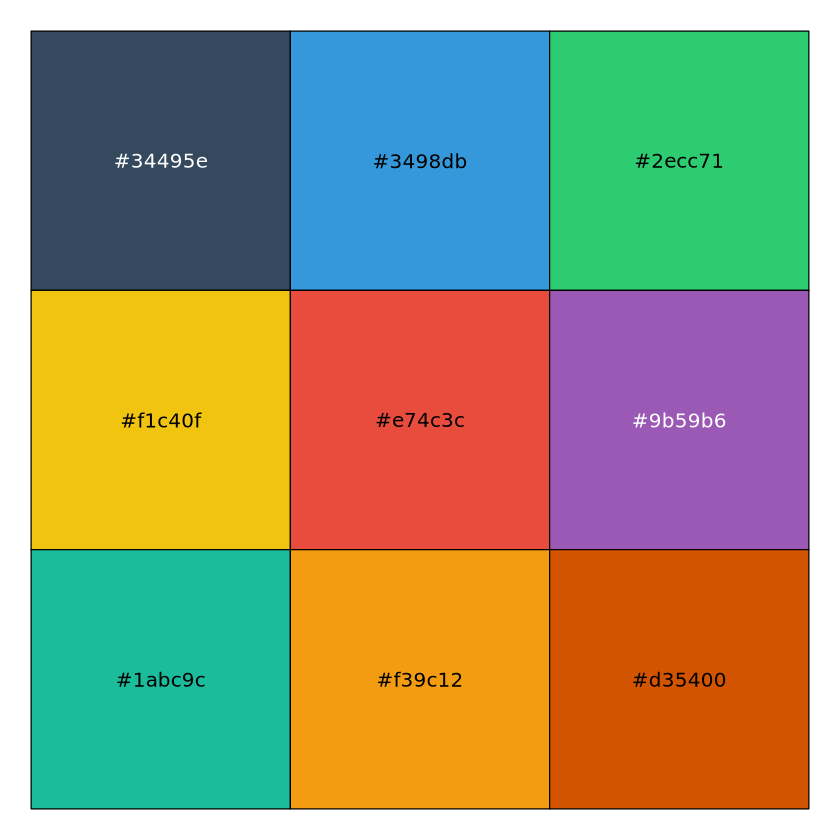

In [85]:
show_col(palettes_d$ggthemr$flat)

In [86]:
unique(all_correlations$Group)

[1] "5hmCG"      "5hmCG+5mCG" "5mCG"       "5hmCH"      "5hmCH+5mCH"
[6] "5mCH"

In [87]:
group.col <- setNames(rev(palettes_d$ggthemr$flat[1:6]),unique(all_correlations$Group))
group.col

5hmCG 5hmCG+5mCG       5mCG      5hmCH 5hmCH+5mCH       5mCH 
 "#9b59b6"  "#e74c3c"  "#f1c40f"  "#2ecc71"  "#3498db"  "#34495e"

In [88]:
all_correlations

chrom100k,correlation,Group
<chr>,<dbl>,<chr>
chr1_100,0.21802421,5hmCG
chr1_1000,0.25930814,5hmCG
chr1_1001,0.27958191,5hmCG
chr1_1002,0.28283620,5hmCG
chr1_1003,0.30686297,5hmCG
chr1_1004,0.30602371,5hmCG
chr1_1005,0.17528066,5hmCG
chr1_1006,0.24865629,5hmCG
chr1_1007,0.17084597,5hmCG


In [89]:
unique(all_correlations$Group)

[1] "5hmCG"      "5hmCG+5mCG" "5mCG"       "5hmCH"      "5hmCH+5mCH"
[6] "5mCH"

In [90]:
levels(all_correlations$Group)

NULL

In [91]:
all_correlations$Group <- factor(all_correlations$Group,
                                 levels = c("5mCH","5hmCH+5mCH","5hmCH","5mCG","5hmCG+5mCG","5hmCG"))

In [92]:
levels(all_correlations$Group)

[1] "5mCH"       "5hmCH+5mCH" "5hmCH"      "5mCG"       "5hmCG+5mCG"
[6] "5hmCG"

In [93]:
library(ggridges)

Warning message:
“package ‘ggridges’ was built under R version 4.3.2”


In [94]:
mean_correlations <- all_correlations %>%
  group_by(Group) %>%
  summarize(mean_correlation = mean(correlation, na.rm = TRUE))
mean_correlations

Group,mean_correlation
<fct>,<dbl>
5mCH,-0.007057521
5hmCH+5mCH,0.005710683
5hmCH,0.092362496
5mCG,-0.140448653
5hmCG+5mCG,-0.075093551
5hmCG,0.093165579


Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”
Picking joint bandwidth of 0.0347

Warning message:
“Removed 1783 rows containing non-finite outside the scale range (`stat_density_ridges()`).”


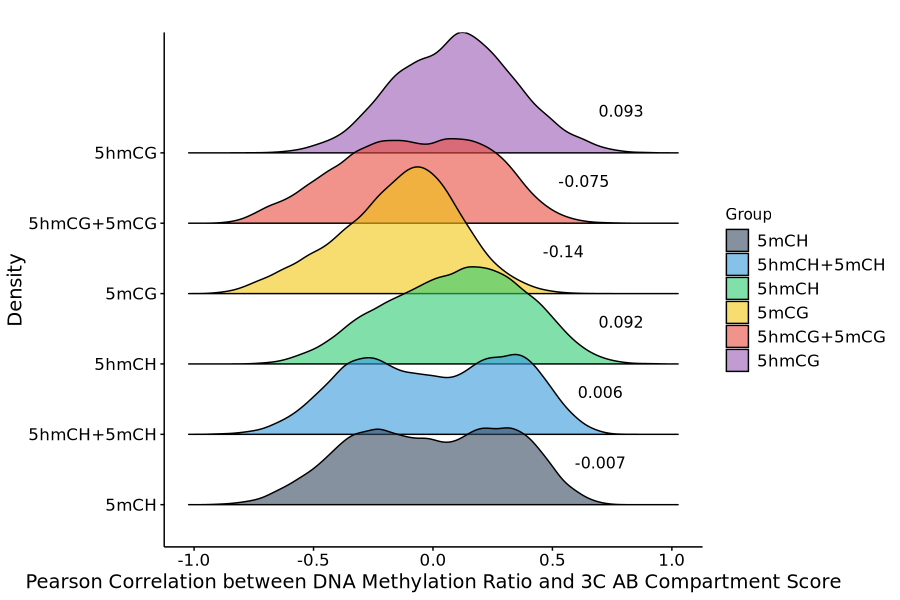

In [95]:
options(repr.plot.width = 9, repr.plot.height = 6, repr.plot.res = 100)
ggplot(data = all_correlations,
       aes(x = correlation, y = Group, fill = Group)) +
  geom_density_ridges2(alpha = 0.6) +
  scale_fill_manual(values = group.col) +
  geom_text(data = mean_correlations,
            aes(label = round(mean_correlation, 3), 
                x = mean_correlation + 0.6,  # 右移标签
                y = as.numeric(factor(Group)) + 0.6),  # 上移标签
            inherit.aes = FALSE, 
            hjust = 0, size = 4) +
  
  theme_classic() +
  labs(
    title = "",
    x = "Pearson Correlation between DNA Methylation Ratio and 3C AB Compartment Score",
    y = "Density"
  ) +
  theme(
    legend.position = "right",
    axis.title = element_text(color = "black", size = 14),
    axis.text = element_text(color = "black", size = 12),
    legend.text = element_text(color = "black", size = 12),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 0.5),
    axis.ticks = element_line(color = "black")
  )

In [96]:
pdf("../output/07-Pearson_Correlation_between_DNA_Methylation_Ratio_and_3C_AB_Compartment_Score_density_ridges_20251030.pdf",width = 6,height = 6)
ggplot(data = all_correlations,
       aes(x = correlation, y = Group, fill = Group)) +
  geom_density_ridges2(alpha = 0.6) +
  scale_fill_manual(values = group.col) +
  geom_text(data = mean_correlations,
            aes(label = round(mean_correlation, 3), 
                x = mean_correlation + 0.6,  # 右移标签
                y = as.numeric(factor(Group)) + 0.6),  # 上移标签
            inherit.aes = FALSE, 
            hjust = 0, size = 4) +
  
  theme_classic() +
  labs(
    title = "",
    x = "Pearson Correlation between DNA Methylation Ratio and 3C AB Compartment Score",
    y = "Density"
  ) +
  theme(
    legend.position = "right",
    axis.title = element_text(color = "black", size = 14),
    axis.text = element_text(color = "black", size = 12),
    legend.text = element_text(color = "black", size = 12),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 0.5),
    axis.ticks = element_line(color = "black")
  )
dev.off()

Picking joint bandwidth of 0.0347

Warning message:
“Removed 1783 rows containing non-finite outside the scale range (`stat_density_ridges()`).”


png 
  2

Picking joint bandwidth of 0.0347

Warning message:
“Removed 1783 rows containing non-finite outside the scale range (`stat_density_ridges()`).”


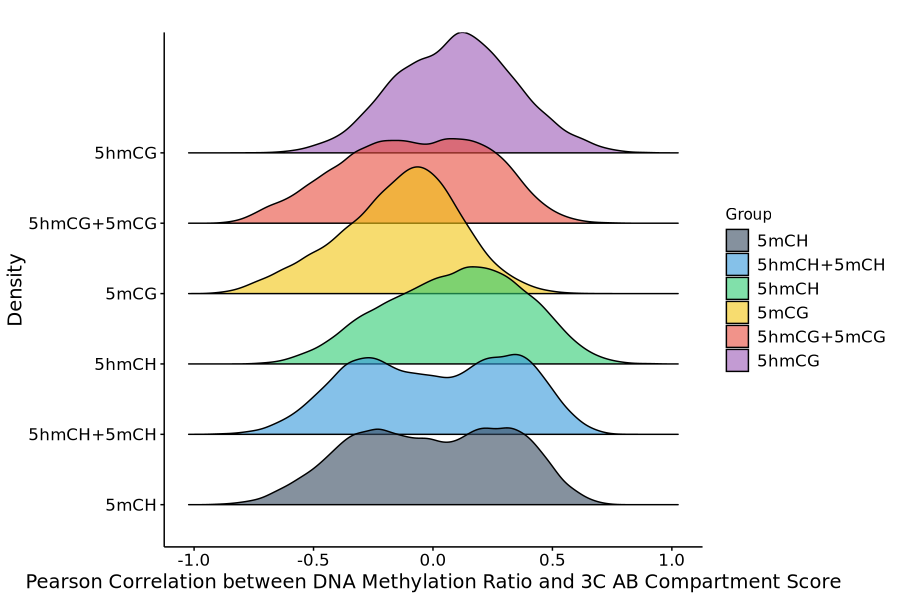

In [97]:
ggplot(data = all_correlations,
       aes(x = correlation, y = Group, fill = Group)) +
geom_density_ridges2(alpha = 0.6) +
scale_fill_manual(values = group.col) +
theme_classic() +
labs(
    title = "",
    x = "Pearson Correlation between DNA Methylation Ratio and 3C AB Compartment Score",
    y = "Density"
  ) +
theme(
    legend.position = "right",
    axis.title = element_text(color = "black", size = 14),
    axis.text = element_text(color = "black", size = 12),
    legend.text = element_text(color = "black", size = 12),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    axis.line = element_line(color = "black", size = 0.5),
    axis.ticks = element_line(color = "black")
  )

In [98]:
head(all_correlations);dim(all_correlations)

chrom100k,correlation,Group
<chr>,<dbl>,<fct>
chr1_100,0.2180242,5hmCG
chr1_1000,0.2593081,5hmCG
chr1_1001,0.2795819,5hmCG
chr1_1002,0.2828362,5hmCG
chr1_1003,0.3068630,5hmCG
chr1_1004,0.3060237,5hmCG


[1] 144191      3

In [99]:
saveRDS(all_correlations,"../output/07-all_correlations_20251030.rds")

In [100]:
top_100_correlation

chrom100k,correlation
<chr>,<dbl>
chr1_684,0.8991851
chr1_681,0.8925215
chr1_685,0.8909193
chr1_688,0.8858125
chr1_683,0.8852501
chr1_686,0.8815367
chr6_91,0.8789643
chr1_687,0.8661270
chr1_682,0.8620788


In [101]:
top_100_correlation[top_100_correlation$chrom100k %in% c('chr7_903','chr5_201','chr2_390','chr8_173','chr8_171','chr8_172'),]

chrom100k,correlation
<chr>,<dbl>
chr8_171,0.7870762
chr8_172,0.7823040
chr2_390,0.7804214
chr5_201,0.7747853
chr8_173,0.7579533
chr7_903,0.7506601
